In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim



df = pd.read_excel(r'updated_fc_predictions_with_fc_hat_all_data.xlsx', sheet_name='28all')
df.dropna(inplace=True)

features = ['PC', 'PC_TYPE','FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a','SCM%', 'CAGG%', 'FAGG%', 'FA%','SS%','SF%']

X = df[features].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)


In [20]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def custom_loss(outputs, targets, inputs, a, b, e, d):
    outputs = outputs.squeeze()  # Remove the extra dimension
    mse_loss = nn.MSELoss()(outputs, targets)

    # Use the constant value of AGE (7) as a tensor
    AGE = torch.tensor(28.0).to(outputs.device)  # Ensure it's on the same device as the outputs
    wb = inputs[:, -8]  # Ensure this is still a valid feature index

    # Calculate predicted fc using the constant AGE
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    mean_square_residual = torch.mean(residual ** 2)

    if mean_square_residual.item() > 0:
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual
    
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    return total_loss




# Training function
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()  # Squeeze to match dimensions
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Hyperparameters
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.00076  # Fixed learning rate

# Initialize model
model = RegressionModel(Xtrain.shape[1], layers, neurons)

# Move model and data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
Xtrain_tensor = torch.FloatTensor(Xtrain).to(device)
ytrain_tensor = torch.FloatTensor(ytrain).to(device)
Xtest_tensor = torch.FloatTensor(Xtest).to(device)

# Define custom parameters
a = 40.5
b = 15.3
e = 6.5
d = 0.36

# Train the model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_model(model, optimizer, Xtrain_tensor, ytrain_tensor, a=a, b=b, e=e, d=d)




In [21]:
# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
wb_ratio_range = np.linspace(X_normal[:, features.index('w/b')].min(), X_normal[:, features.index('w/b')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (wb_ratio_range.size, 1)), columns=features)
pdp_data['w/b'] = wb_ratio_range  # Vary FA%

# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
pdp_predictions_normalized = model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['w/b'] * x_std[features.index('w/b')] + x_mean[features.index('w/b')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'w/b(Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_KINN_28_wb.csv', index=False)

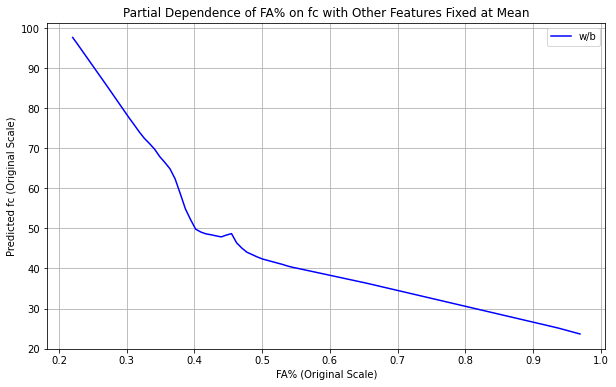

In [22]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='w/b', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()